# Generalized Additive Models (GAM) Tutorial

This tutorial demonstrates how to use Aurora-GLM's GAM implementation for flexible non-linear modeling.

## Table of Contents

1. [Introduction to GAMs](#introduction)
2. [Univariate GAM: Single Smooth Term](#univariate)
3. [Multivariate GAM: Multiple Smooth Terms](#multivariate)
4. [Mixed Models: Smooth + Parametric Terms](#mixed)
5. [R-style Formula Interface](#formula)
6. [Smoothing Parameter Selection: GCV vs REML](#smoothing)
7. [Basis Function Types](#basis)
8. [Model Diagnostics and Visualization](#diagnostics)
9. [Real-World Example: Environmental Data](#realworld)
10. [Advanced Topics](#advanced)

## 1. Introduction to GAMs <a id="introduction"></a>

Generalized Additive Models extend linear models by allowing non-linear relationships between predictors and response:

$$y = \beta_0 + f_1(x_1) + f_2(x_2) + \cdots + \epsilon$$

where $f_j$ are smooth functions estimated from data using penalized splines.

### Key Advantages:
- Capture non-linear patterns automatically
- Interpretable: each term shows effect of one variable
- Flexible: balance between smoothness and fit
- Fast: efficient algorithms for large datasets

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.models.gam import (
    fit_gam,
    fit_additive_gam,
    fit_gam_formula,
    SmoothTerm,
    ParametricTerm,
    plot_smooth,
    plot_all_smooths,
)

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Univariate GAM: Single Smooth Term <a id="univariate"></a>

Let's start with a simple case: modeling a non-linear relationship with one predictor.

In [2]:
# Generate synthetic data with non-linear relationship
n = 200
x = np.linspace(0, 4*np.pi, n)
y_true = np.sin(x) + 0.5 * np.cos(2*x)
y = y_true + 0.3 * np.random.randn(n)

# Fit GAM with single smooth term
result = fit_gam(x, y, n_basis=15)

print(result.summary())

Generalized Additive Model (GAM) - Fitted Summary

Model Information:
  Basis type:          BSplineBasis
  Number of basis:     15
  Observations:        200

Smoothing:
  Lambda:              2.437597e-02
  Effective DoF:       13.86
  GCV score:           8.460597e-02

Fit Statistics:
  Residual sum sq:     14.6567
  R-squared:           0.8869
  Residual std:        0.2707

Residuals:
  Min:                 -0.8904
  Q1:                  -0.1806
  Median:              -0.0081
  Q3:                  0.1623
  Max:                 0.7323



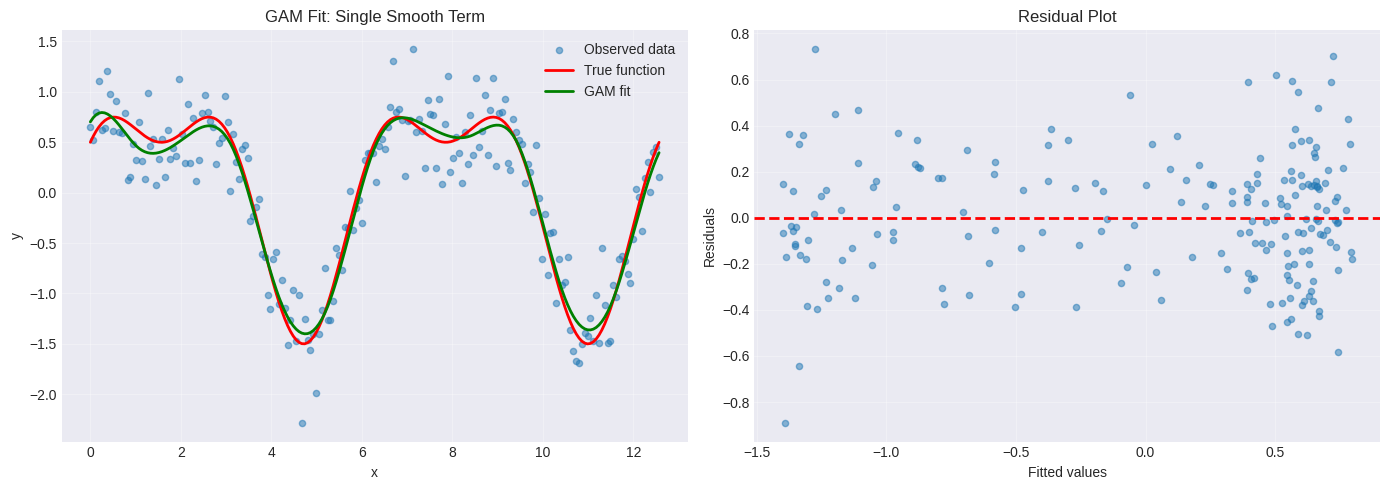


Model R²: 0.8869
Effective degrees of freedom: 13.86
Optimal lambda: 0.024376


In [3]:
# Visualize the fit
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot smooth function
ax1.scatter(x, y, alpha=0.5, s=20, label='Observed data')
ax1.plot(x, y_true, 'r-', linewidth=2, label='True function')
ax1.plot(x, result.fitted_values, 'g-', linewidth=2, label='GAM fit')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('GAM Fit: Single Smooth Term')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot residuals
ax2.scatter(result.fitted_values, result.residuals, alpha=0.5, s=20)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('Fitted values')
ax2.set_ylabel('Residuals')
ax2.set_title('Residual Plot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nModel R²: {result.r_squared:.4f}")
print(f"Effective degrees of freedom: {result.edf:.2f}")
print(f"Optimal lambda: {result.lambda_opt:.6f}")

## 3. Multivariate GAM: Multiple Smooth Terms <a id="multivariate"></a>

Now let's model with multiple predictors, each with its own smooth function:

$$y = \beta_0 + f_1(x_1) + f_2(x_2) + \epsilon$$

In [4]:
# Generate data with two non-linear effects
n = 300
X = np.random.randn(n, 2)

# True model: y = sin(2πx₁) + cos(x₂) + noise
y_true = 2 * np.sin(2 * np.pi * X[:, 0]) + 3 * np.cos(X[:, 1])
y = y_true + 0.5 * np.random.randn(n)

# Fit additive GAM
result = fit_additive_gam(
    X, y,
    smooth_terms=[
        SmoothTerm(variable=0, n_basis=15),
        SmoothTerm(variable=1, n_basis=15)
    ]
)

print(result.summary())

Additive Generalized Additive Model (GAM) - Fitted Summary

Model Structure:
  Smooth terms:        2
  Parametric terms:    0
  Observations:        300
  Total EDF:           29.70

Smooth Terms:
  s(0):
    Basis:             bspline
    n_basis:           15
    Lambda:            6.820589e-04
    EDF:               15.27
  s(1):
    Basis:             bspline
    n_basis:           15
    Lambda:            6.820589e-04
    EDF:               13.43

Fit Statistics:
  Residual sum sq:     194.9626
  R-squared:           0.8456
  Residual std:        0.8061
  GCV score:           7.823579e-01

Residuals:
  Min:                 -2.4510
  Q1:                  -0.4419
  Median:              -0.0371
  Q3:                  0.4850
  Max:                 2.2966



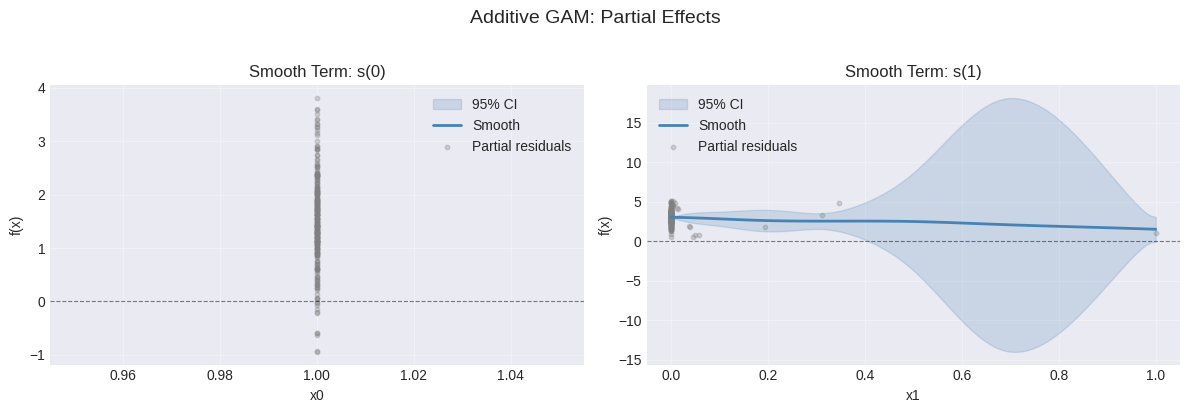


Model R²: 0.8456
Total EDF: 29.70

Per-term EDF:
  s(0): 15.27
  s(1): 13.43


In [6]:
# Visualize both smooth terms
fig = plot_all_smooths(result)
plt.suptitle('Additive GAM: Partial Effects', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nModel R²: {result.r_squared:.4f}")
print(f"Total EDF: {result.total_edf_:.2f}")
print(f"\nPer-term EDF:")
for term_name, edf in result.edf_values.items():
    print(f"  {term_name}: {edf:.2f}")


## 4. Mixed Models: Smooth + Parametric Terms <a id="mixed"></a>

Often we want to combine smooth non-linear effects with regular linear effects:

$$y = \beta_0 + f(x_1) + \beta_2 x_2 + \beta_3 x_3 + \epsilon$$

In [7]:
# Generate mixed data
n = 250
X = np.random.randn(n, 3)

# True model: smooth effect + linear effects
y = (np.sin(3 * X[:, 0]) +      # Non-linear effect
     2.5 * X[:, 1] +             # Linear effect
     -1.5 * X[:, 2] +            # Linear effect
     0.3 * np.random.randn(n))

# Fit mixed GAM
result = fit_additive_gam(
    X, y,
    smooth_terms=[SmoothTerm(variable=0, n_basis=12)],
    parametric_terms=[
        ParametricTerm(variable=1),
        ParametricTerm(variable=2)
    ]
)

print(result.summary())

print("\n" + "="*50)
print("COEFFICIENT COMPARISON")
print("="*50)
print(f"Intercept: {result.parametric_coef[0]:.4f} (true ≈ 0)")
print(f"x₁ (linear): {result.parametric_coef[1]:.4f} (true = 2.5)")
print(f"x₂ (linear): {result.parametric_coef[2]:.4f} (true = -1.5)")

Additive Generalized Additive Model (GAM) - Fitted Summary

Model Structure:
  Smooth terms:        1
  Parametric terms:    2
  Observations:        250
  Total EDF:           14.82

Parametric Coefficients:
  Intercept:           0.2773
  1:             2.4576
  2:             -1.5146

Smooth Terms:
  s(0):
    Basis:             bspline
    n_basis:           12
    Lambda:            4.216861e-03
    EDF:               11.82

Fit Statistics:
  Residual sum sq:     22.6051
  R-squared:           0.9903
  Residual std:        0.3007
  GCV score:           1.021710e-01

Residuals:
  Min:                 -0.9477
  Q1:                  -0.2047
  Median:              0.0213
  Q3:                  0.1766
  Max:                 0.9423


COEFFICIENT COMPARISON
Intercept: 0.2773 (true ≈ 0)
x₁ (linear): 2.4576 (true = 2.5)
x₂ (linear): -1.5146 (true = -1.5)


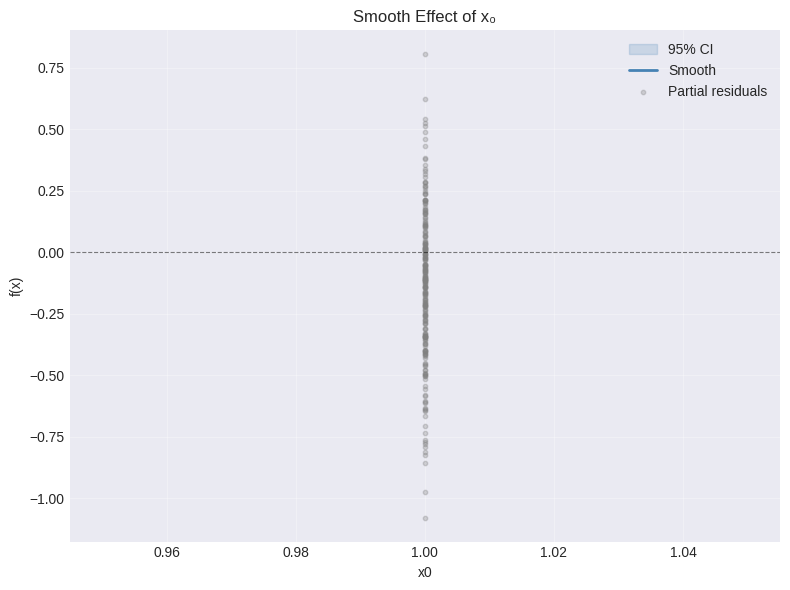

In [9]:
# Visualize smooth term
plot_smooth(result, term='s(0)')
plt.title('Smooth Effect of x₀')
plt.show()


## 5. R-style Formula Interface <a id="formula"></a>

Aurora provides an R-style formula interface for convenient model specification:

In [10]:
# Using dict with named variables
n = 200
temperature = np.random.uniform(15, 35, n)
humidity = np.random.uniform(30, 90, n)
altitude = np.random.uniform(0, 2000, n)

# Simulated crop yield
yield_data = (
    50 +
    10 * np.sin(0.15 * temperature) +  # Non-linear temperature effect
    5 * np.exp(-0.02 * humidity) +      # Non-linear humidity effect
    0.01 * altitude +                   # Linear altitude effect
    3 * np.random.randn(n)
)

# Create data dict
data = {
    'yield': yield_data,
    'temp': temperature,
    'humid': humidity,
    'alt': altitude
}

# Fit using formula
result = fit_gam_formula(
    "yield ~ s(temp, n_basis=12) + s(humid, n_basis=12) + alt",
    data
)

print(result.summary())

Additive Generalized Additive Model (GAM) - Fitted Summary

Model Structure:
  Smooth terms:        2
  Parametric terms:    1
  Observations:        200
  Total EDF:           7.30

Parametric Coefficients:
  Intercept:           703.6684
  0:             0.0102

Smooth Terms:
  s(2):
    Basis:             bspline
    n_basis:           12
    Lambda:            1.055986e+01
    EDF:               5.30
  s(1):
    Basis:             bspline
    n_basis:           12
    Lambda:            1.055986e+01
    EDF:               0.00

Fit Statistics:
  Residual sum sq:     1579.4355
  R-squared:           0.8976
  Residual std:        2.8102
  GCV score:           5.101603e+00

Residuals:
  Min:                 -7.4441
  Q1:                  -1.7846
  Median:              0.0642
  Q3:                  1.7593
  Max:                 8.1500



In [11]:
# Using array with column indices
X = np.random.randn(200, 3)
y = np.sin(X[:, 0]) + 2*X[:, 1] + 0.5*X[:, 2] + 0.2*np.random.randn(200)
data_array = np.column_stack([y, X])

result = fit_gam_formula("0 ~ s(1) + 2 + 3", data_array)
print(f"\nR² = {result.r_squared:.4f}")



R² = 0.9918


## 6. Smoothing Parameter Selection: GCV vs REML <a id="smoothing"></a>

Aurora supports two methods for automatic smoothing parameter selection:

- **GCV (Generalized Cross-Validation)**: Fast, works well for most cases
- **REML (Restricted Maximum Likelihood)**: More theoretically justified, can be more stable

In [12]:
# Generate test data
n = 200
X = np.random.randn(n, 2)
y = np.sin(2*X[:, 0]) + np.cos(X[:, 1]) + 0.2*np.random.randn(n)

# Fit with GCV
result_gcv = fit_additive_gam(
    X, y,
    smooth_terms=[
        SmoothTerm(variable=0, n_basis=15),
        SmoothTerm(variable=1, n_basis=15)
    ],
    method="GCV"
)

# Fit with REML
result_reml = fit_additive_gam(
    X, y,
    smooth_terms=[
        SmoothTerm(variable=0, n_basis=15),
        SmoothTerm(variable=1, n_basis=15)
    ],
    method="REML"
)

print("="*60)
print("GCV vs REML COMPARISON")
print("="*60)
print(f"\nGCV Method:")
print(f"  Lambda: {result_gcv.lambda_values['s(0)']:.6f}")
print(f"  Total EDF: {result_gcv.total_edf_:.2f}")
print(f"  R²: {result_gcv.r_squared:.4f}")

print(f"\nREML Method:")
print(f"  Lambda: {result_reml.lambda_values['s(0)']:.6f}")
print(f"  Total EDF: {result_reml.total_edf_:.2f}")
print(f"  R²: {result_reml.r_squared:.4f}")


GCV vs REML COMPARISON

GCV Method:
  Lambda: 0.000687
  Total EDF: 29.36
  R²: 0.9525

REML Method:
  Lambda: 999994.359589
  Total EDF: 3.00
  R²: 0.1881


## 7. Basis Function Types <a id="basis"></a>

Aurora supports different types of basis functions:

- **B-splines** (default): Fast, flexible, good for most cases
- **Cubic splines**: Natural cubic splines with automatic knot placement

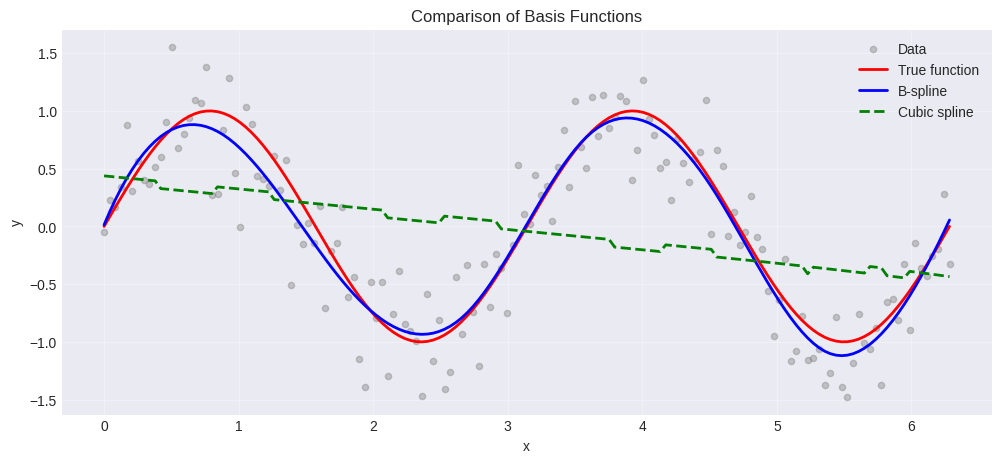

B-spline EDF: 6.92
Cubic spline EDF: 1.00


In [13]:
# Generate data
n = 150
x = np.linspace(0, 2*np.pi, n)
y_true = np.sin(2*x)
y = y_true + 0.3*np.random.randn(n)
X = x.reshape(-1, 1)

# Fit with B-splines
result_bspline = fit_additive_gam(
    X, y,
    smooth_terms=[SmoothTerm(variable=0, basis_type='bspline', n_basis=10)]
)

# Fit with cubic splines
result_cubic = fit_additive_gam(
    X, y,
    smooth_terms=[SmoothTerm(variable=0, basis_type='cubic', n_basis=10)]
)

# Plot comparison
plt.figure(figsize=(12, 5))
plt.scatter(x, y, alpha=0.4, s=20, label='Data', c='gray')
plt.plot(x, y_true, 'r-', linewidth=2, label='True function')
plt.plot(x, result_bspline.fitted_values, 'b-', linewidth=2, label='B-spline')
plt.plot(x, result_cubic.fitted_values, 'g--', linewidth=2, label='Cubic spline')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of Basis Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"B-spline EDF: {result_bspline.total_edf_:.2f}")
print(f"Cubic spline EDF: {result_cubic.total_edf_:.2f}")

## 8. Model Diagnostics and Visualization <a id="diagnostics"></a>

Always check model diagnostics to ensure good fit:

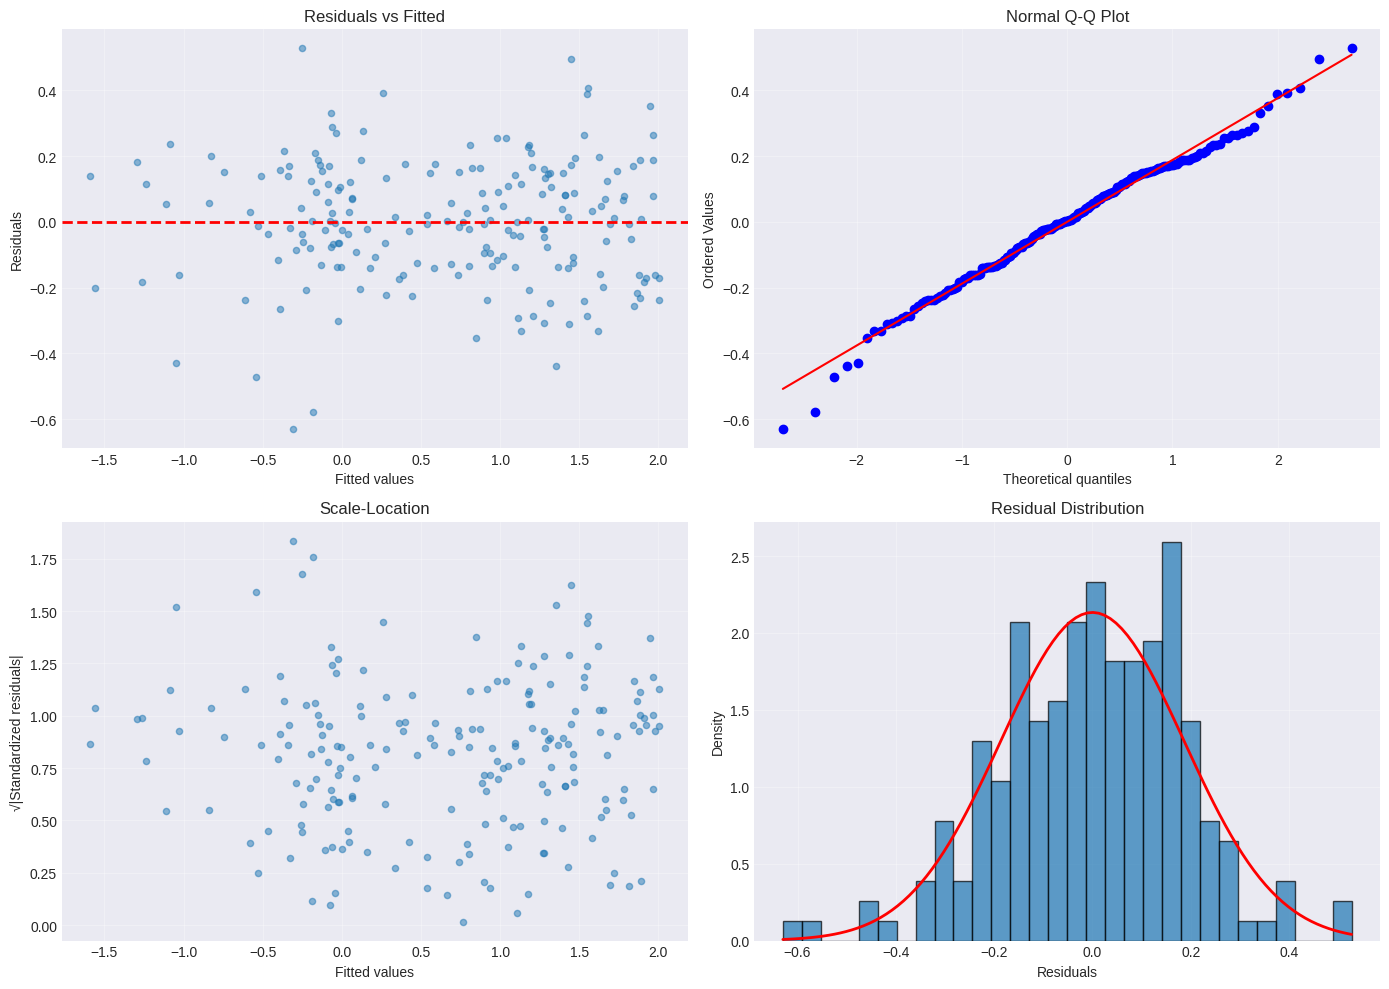

In [14]:
# Fit a model
n = 200
X = np.random.randn(n, 2)
y = np.sin(2*X[:, 0]) + np.cos(X[:, 1]) + 0.2*np.random.randn(n)

result = fit_additive_gam(
    X, y,
    smooth_terms=[
        SmoothTerm(variable=0, n_basis=12),
        SmoothTerm(variable=1, n_basis=12)
    ]
)

# Create diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(result.fitted_values, result.residuals, alpha=0.5, s=20)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q Plot
from scipy import stats
stats.probplot(result.residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Scale-Location
standardized_resid = result.residuals / np.std(result.residuals)
axes[1, 0].scatter(result.fitted_values, np.sqrt(np.abs(standardized_resid)), alpha=0.5, s=20)
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel('√|Standardized residuals|')
axes[1, 0].set_title('Scale-Location')
axes[1, 0].grid(True, alpha=0.3)

# 4. Histogram of residuals
axes[1, 1].hist(result.residuals, bins=30, density=True, alpha=0.7, edgecolor='black')
x_range = np.linspace(result.residuals.min(), result.residuals.max(), 100)
axes[1, 1].plot(x_range, stats.norm.pdf(x_range, 0, np.std(result.residuals)), 'r-', linewidth=2)
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Residual Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Real-World Example: Environmental Data <a id="realworld"></a>

Let's apply GAMs to a realistic environmental dataset.

In [15]:
# Simulate realistic environmental data
np.random.seed(123)
n = 500

# Predictors
day_of_year = np.random.uniform(1, 365, n)
temperature = 15 + 10*np.sin(2*np.pi*day_of_year/365) + 3*np.random.randn(n)
wind_speed = np.random.gamma(3, 2, n)
humidity = np.random.uniform(40, 90, n)

# Response: Air quality index (simulated)
aqi = (
    50 +
    20*np.sin(2*np.pi*day_of_year/365) +     # Seasonal effect
    15*np.exp(temperature/30) +               # Non-linear temp effect
    -5*np.sqrt(wind_speed) +                  # Wind disperses pollution
    0.3*humidity +                            # Linear humidity effect
    10*np.random.randn(n)
)

# Create dataset
env_data = {
    'aqi': aqi,
    'day': day_of_year,
    'temp': temperature,
    'wind': wind_speed,
    'humid': humidity
}

# Fit GAM model
result = fit_gam_formula(
    "aqi ~ s(day, n_basis=20) + s(temp, n_basis=15) + s(wind, n_basis=12) + humid",
    env_data,
    method="GCV"
)

print(result.summary())

Additive Generalized Additive Model (GAM) - Fitted Summary

Model Structure:
  Smooth terms:        3
  Parametric terms:    1
  Observations:        500
  Total EDF:           2.00

Parametric Coefficients:
  Intercept:           -4000.5048
  1:             0.3011

Smooth Terms:
  s(0):
    Basis:             bspline
    n_basis:           20
    Lambda:            2.906971e+01
    EDF:               0.00
  s(2):
    Basis:             bspline
    n_basis:           15
    Lambda:            2.906971e+01
    EDF:               0.00
  s(3):
    Basis:             bspline
    n_basis:           12
    Lambda:            2.906971e+01
    EDF:               0.00

Fit Statistics:
  Residual sum sq:     47534.5690
  R-squared:           0.8264
  Residual std:        9.7503
  GCV score:           8.165761e+01

Residuals:
  Min:                 -26.8444
  Q1:                  -5.6256
  Median:              0.2386
  Q3:                  6.3202
  Max:                 29.8024



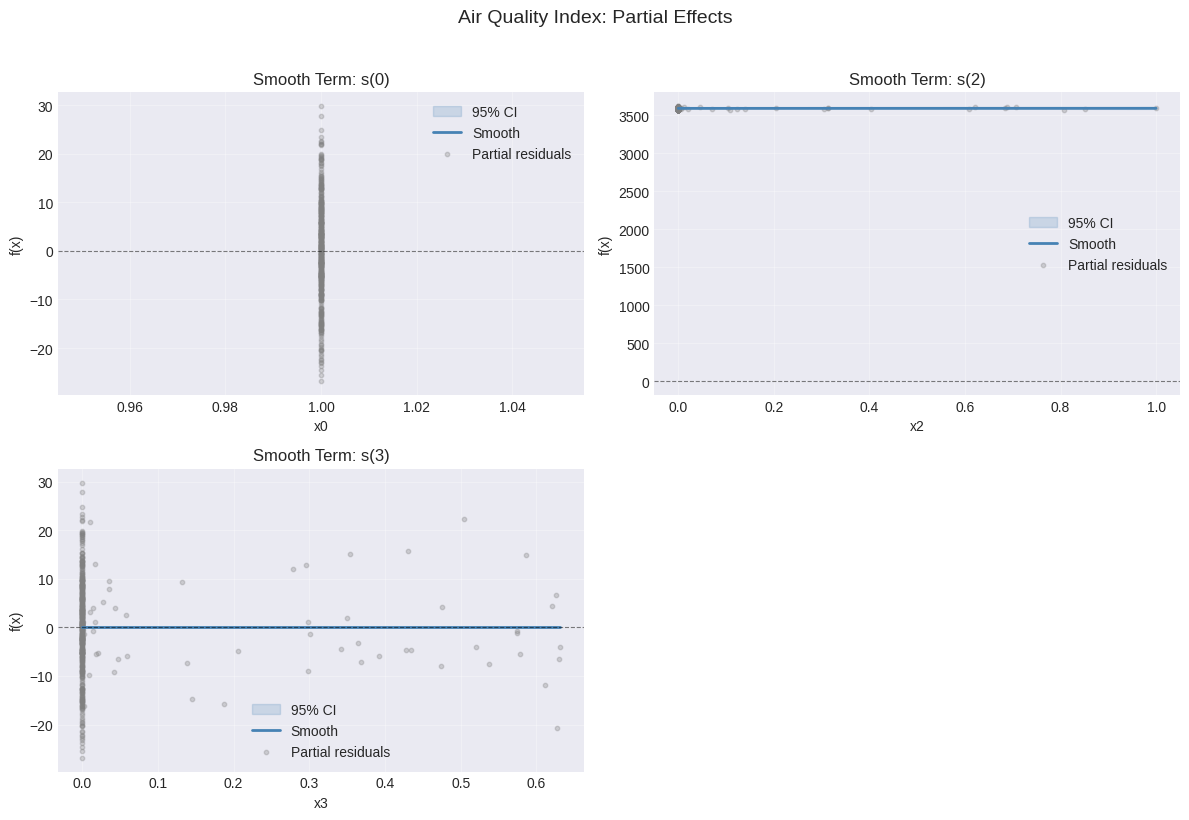


MODEL PERFORMANCE
R² = 0.8264
MAE = 7.68
RMSE = 9.75

Linear humidity effect: 0.3011 (true ≈ 0.3)


In [16]:
# Visualize partial effects
fig = plot_all_smooths(result)
plt.suptitle('Air Quality Index: Partial Effects', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Model performance
r2 = result.r_squared
mae = np.mean(np.abs(result.residuals))
rmse = np.sqrt(np.mean(result.residuals**2))

print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"R² = {r2:.4f}")
print(f"MAE = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"\nLinear humidity effect: {result.parametric_coef[1]:.4f} (true ≈ 0.3)")


## 10. Advanced Topics <a id="advanced"></a>

### Controlling Smoothness

You can control the smoothness by:
1. Number of basis functions (`n_basis`)
2. Penalty order (`penalty_order`)
3. Fixed smoothing parameter (`lambda_`)

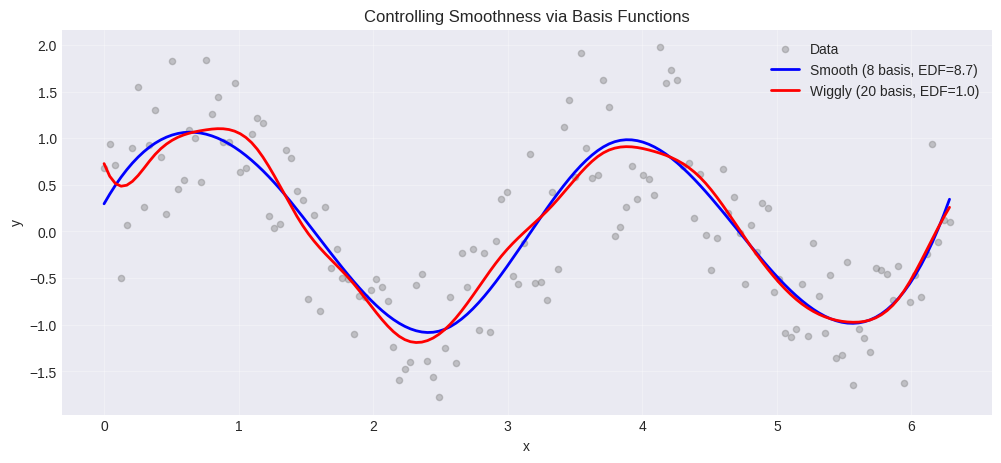

In [17]:
# Generate noisy data
n = 150
x = np.linspace(0, 2*np.pi, n)
y = np.sin(2*x) + 0.5*np.random.randn(n)
X = x.reshape(-1, 1)

# Fit with different smoothness levels
result_smooth = fit_additive_gam(
    X, y,
    smooth_terms=[SmoothTerm(variable=0, n_basis=8)]  # Fewer basis = smoother
)

result_wiggly = fit_additive_gam(
    X, y,
    smooth_terms=[SmoothTerm(variable=0, n_basis=20)]  # More basis = more flexible
)

# Plot
plt.figure(figsize=(12, 5))
plt.scatter(x, y, alpha=0.4, s=20, label='Data', c='gray')
plt.plot(x, result_smooth.fitted_values, 'b-', linewidth=2, label=f'Smooth (8 basis, EDF={result_smooth.total_edf_:.1f})')
plt.plot(x, result_wiggly.fitted_values, 'r-', linewidth=2, label=f'Wiggly (20 basis, EDF={result_wiggly.total_edf_:.1f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Controlling Smoothness via Basis Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Observation Weights

When you have heterogeneous variance or want to down-weight outliers:

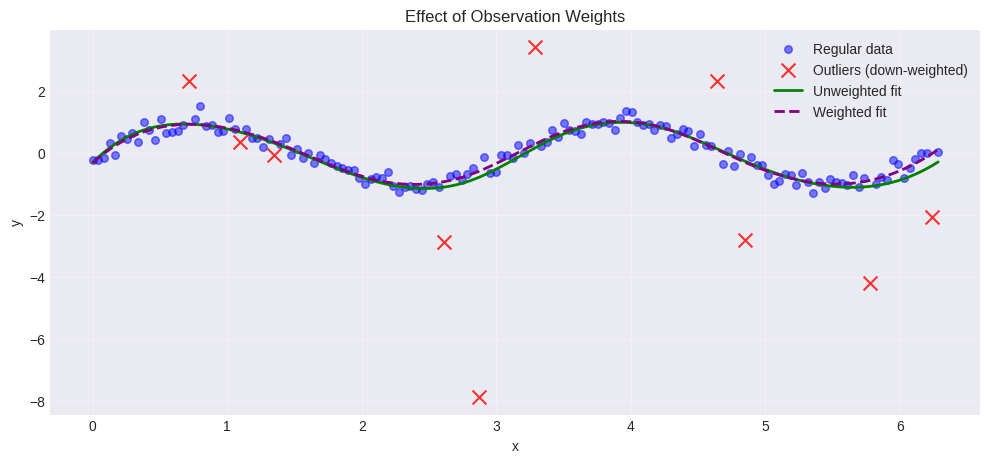

In [18]:
# Generate data with outliers
n = 150
x = np.linspace(0, 2*np.pi, n)
y = np.sin(2*x) + 0.2*np.random.randn(n)

# Add some outliers
outlier_idx = np.random.choice(n, 10, replace=False)
y[outlier_idx] += 3 * np.random.randn(10)

# Create weights (down-weight outliers)
weights = np.ones(n)
weights[outlier_idx] = 0.1

X = x.reshape(-1, 1)

# Fit without weights
result_unweighted = fit_additive_gam(
    X, y,
    smooth_terms=[SmoothTerm(variable=0, n_basis=12)]
)

# Fit with weights
result_weighted = fit_additive_gam(
    X, y,
    smooth_terms=[SmoothTerm(variable=0, n_basis=12)],
    weights=weights
)

# Plot
plt.figure(figsize=(12, 5))
plt.scatter(x[~np.isin(range(n), outlier_idx)], y[~np.isin(range(n), outlier_idx)], 
           alpha=0.5, s=30, label='Regular data', c='blue')
plt.scatter(x[outlier_idx], y[outlier_idx], alpha=0.8, s=100, 
           label='Outliers (down-weighted)', c='red', marker='x')
plt.plot(x, result_unweighted.fitted_values, 'g-', linewidth=2, label='Unweighted fit')
plt.plot(x, result_weighted.fitted_values, 'purple', linewidth=2, linestyle='--', label='Weighted fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Effect of Observation Weights')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary

This tutorial covered:

✅ Basic GAM concepts and univariate smoothing  
✅ Multivariate additive models  
✅ Mixed smooth and parametric effects  
✅ R-style formula interface  
✅ Smoothing parameter selection (GCV vs REML)  
✅ Different basis function types  
✅ Model diagnostics and visualization  
✅ Real-world environmental data example  
✅ Advanced topics: smoothness control and weights  

### Next Steps

- Explore tensor product smooths for interactions (coming soon)
- Try thin plate splines for multidimensional surfaces (coming soon)
- Apply GAMs to your own data!

### Resources

- [Aurora-GLM Documentation](https://github.com/matcraft94/aurora-glm)
- Wood, S.N. (2017). *Generalized Additive Models: An Introduction with R*
- Hastie, T. & Tibshirani, R. (1990). *Generalized Additive Models*